## Modelling of McDonald's Store Reviews

Objective: Identify the main themes in McDonald's customer reviews using Latent Dirichlet Allocation (LDA), so management can understand customer concerns at scale without reading every review manually.

Dataset: McDonald's Store Reviews (Kaggle) — 33,396 reviews across 40 US store locations, including rating, review text, store address, and relative review time.

This notebook covers all five project stages: exploration, preprocessing, LDA modelling, interpretation, and business recommendations.

**Tasks 1: Explore the Dataset**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [3]:
store = pd.read_csv('/content/McDonald_s_Reviews.csv', encoding='latin1')
store.head()

,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
0,1,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,Why does it look like someone spit on my food?...,1 star
1,2,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,It'd McDonalds. It is what it is as far as the...,4 stars
2,3,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,Made a mobile order got to the speaker and che...,1 star
3,4,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",a month ago,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5 stars
4,5,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",2 months ago,"I repeat my order 3 times in the drive thru, a...",1 star


1.2 How many reviews are in the dataset?

In [4]:
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33396 entries, 0 to 33395
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   reviewer_id    33396 non-null  int64  
 1   store_name     33396 non-null  object 
 2   category       33396 non-null  object 
 3   store_address  33396 non-null  object 
 4   latitude       32736 non-null  float64
 5   longitude      32736 non-null  float64
 6   rating_count   33396 non-null  object 
 7   review_time    33396 non-null  object 
 8   review         33396 non-null  object 
 9   rating         33396 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 2.5+ MB


Interpretation: The dataset containns 33,396 reviews and 10 columns: revieewer ID, store name, category, store address, latitude, longitude, rating count for the store, review time (relative, e.g. "3 months ago"), the review text, and the star rating.

1.3 Are there any missing values?

In [5]:
from pandas._libs import missing
missing_values = store.isnull().sum()
missing_values

,0
reviewer_id,0
store_name,0
category,0
store_address,0
latitude,660
longitude,660
rating_count,0
review_time,0
review,0
rating,0


Only latitude and longitude have missing values (660 rows, about 2% of the data). These two columns are not needed for topic modelling, so they can be left as is or dropped without affecting the analysis. The review column, which is the core input for LDA, has no missing values.

let me check for the duplicate rows too, since duplicate reviews would bias the topic model toward repeated content.

In [6]:
store.duplicated().sum()

np.int64(0)

In [7]:
store['review'].duplicated().sum()

np.int64(11111)

There are no duplicated rows. Some review text repeats appear (short reviews like "Good" can occur from different reviewers), which is expected and not a data quality issue.

1.4 What is the distribution of customer ratings?

In [8]:
# The rating column is stored as text, e.g. "1 star", "4 stars". Extract the numeric value.
# Ensure the 'rating' column is of object (string) type before applying .str accessor
if store['rating'].dtype != 'int64': # Check if it's not already converted to int
    store['rating'] = store['rating'].str.extract(r'(\d+)').astype(int)

ratings_num = store['rating'].value_counts().sort_index()
ratings_pct = (ratings_num / ratings_num.sum() * 100).round(1)
pd.DataFrame({'count': ratings_num, 'pct': ratings_pct})

,count,pct
rating,,
1,9431,28.2
2,3086,9.2
3,4818,14.4
4,5787,17.3
5,10274,30.8


Converting rating from text to a number makes it usable for calculations and plots. Ratings are stored inconsistently as "1 star" vs "4 stars" (singular/plural), so a regex is used to pull out just the digit.

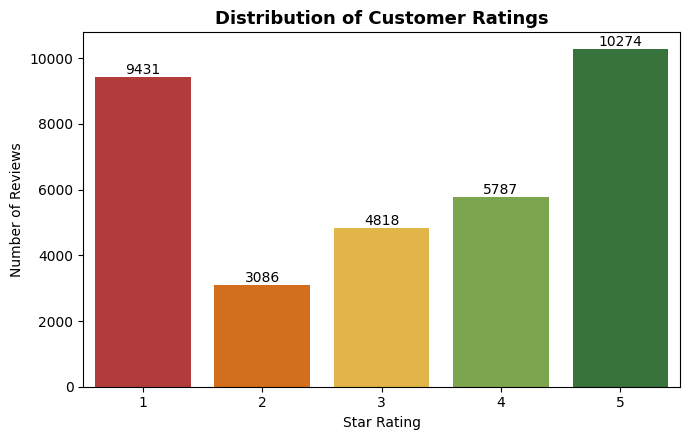

In [9]:
fig, ax =plt.subplots(figsize=(7,4.5))
colors = ["#c62828", "#ef6c00", "#fbc02d", "#7cb342", "#2e7d32"]
sns.countplot(data=store, x="rating", hue="rating", palette=colors, legend=False, ax=ax)
ax.set_title("Distribution of Customer Ratings", fontsize=13, weight="bold")
ax.set_xlabel("Star Rating")
ax.set_ylabel("Number of Reviews")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.savefig("rating_distribution.png")
plt.show()

# Visualisation 1

Rating distribution. The ratings follow a bimodal pattern rather than a normal distribution. 1-star reviews (9,431, 28%) and 5-star reviews (10,274, 31%) are both common, while the middle ratings (2, 3, 4 stars) are less frequent. This means customers tend to have strongly positive or strongly negative experiences, with fewer neutral opinions. This is useful context for the topic model: the extracted topics likely will split cleanly into complaint themes and praise themes.



1.5 Reviews by store location

In [10]:
print(f"Number of unique store locations: {store['store_address'].nunique()}")

top_stores = store["store_address"].value_counts().head(10)
top_stores

Number of unique store locations: 40


,count
store_address,
"9814 International Dr, Orlando, FL 32819, United States",1890
"5725 W Irlo Bronson Memorial Hwy, Kissimmee, FL 34746, United States",1720
"10901 Riverside Dr, North Hollywood, CA 91602, United States",1710
"1415 E State Rd, Fern Park, FL 32730, United States",1700
"632 S R L Thornton Freeway Service Rd, Dallas, TX 75203, United States",1650
"3501 Biscayne Blvd, Miami, FL 33137, United States",1570
"621 Broadway, Newark, NJ 07104, United States",1290
"1100 N US Hwy 377, Roanoke, TX 76262, United States",1168
"72-69 Kissena Blvd, Queens, NY 11367, United States",1140


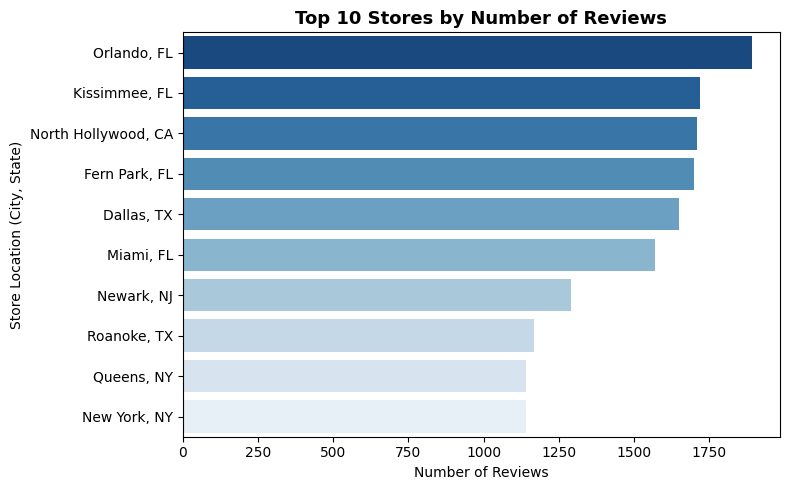

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
# Shorten address labels to city, state for readability
short_labels = [addr.split(",")[1].strip() + ", " + addr.split(",")[2].strip().split(" ")[0] for addr in top_stores.index]
sns.barplot(x=top_stores.values, y=short_labels, hue=short_labels, palette="Blues_r", legend=False, ax=ax)
ax.set_title("Top 10 Stores by Number of Reviews", fontsize=13, weight="bold")
ax.set_xlabel("Number of Reviews")
ax.set_ylabel("Store Location (City, State)")
plt.tight_layout()
plt.savefig("top_stores.png")
plt.show()

#Visualisation 2

Reviews by store. The dataset covers 40 store locations across the US, but review volume is uneven. A handful of stores (Orlando FL, Kissimmee FL, North Hollywood CA) account for a disproportionate share of reviews, likely because they are near tourist attractions with high foot traffic. This matters for Interpretation: topics driven by high-volume stores could dominate the model, so findings should be read as overall customer sentiment rather than being evenly representative of every location.



1.6 Review length and review recency

In [12]:
store["review_length"] = store["review"].str.len()
store["review_length"].describe()

,review_length
count,33396.000000
mean,125.903042
std,184.000878
min,1.000000
25%,17.000000
50%,63.000000
75%,160.000000
max,3115.000000


Review length ranges from 1 to 3,115 characters, with a median of 63 characters. Most reviews are short. This tells us the corpus is dominated by brief comments, so the preprocessing and LDA model need to handle short documents well (a known challenge for LDA, since it performs best on longer documents with richer word co-occurrence).

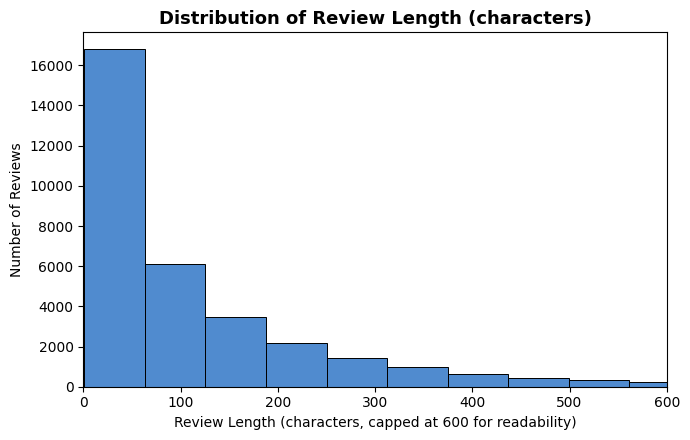

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(store["review_length"], bins=50, ax=ax, color="#1565c0")
ax.set_xlim(0, 600)
ax.set_title("Distribution of Review Length (characters)", fontsize=13, weight="bold")
ax.set_xlabel("Review Length (characters, capped at 600 for readability)")
ax.set_ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig("review_length_distribution.png")
plt.show()

### 1.7 Summary of task 1 findings

- The dataset contains 33,396 reviews from 40 McDonald's store locations across the US.
- Missing values are limited to `latitude` and `longitude` (2% of rows) and do not affect the text used for modelling.
- There are no duplicate rows.
- Ratings are bimodal: strong 5-star and strong 1-star reviews dominate, with fewer 2, 3, and 4-star reviews. This suggests customers write reviews mainly when they are either very satisfied or very dissatisfied.
- Review volume is concentrated in a small number of high-traffic stores.
- Most reviews are short (median 63 characters), so the LDA model will need short-document-friendly settings, which will be addressed in preprocessing and model tuning.

**Task 2: Preprocess the Text**

LDA works by looking at which words co-occur across documents. It cannot read raw sentences. Preprocessing turns messy, human-written review text into a clean list of meaningful word units the model can count and compare. Each step below removes a specific kind of noise.

#2.1 Set up NLTK resources

In [14]:
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

# 2.2 Step 1 — Convert text to lowercase

In [16]:
store["review_clean"] = store["review"].astype(str).str.lower()
store[["review", "review_clean"]].head(5)

,review,review_clean
0,Why does it look like someone spit on my food?...,why does it look like someone spit on my food?...
1,It'd McDonalds. It is what it is as far as the...,it'd mcdonalds. it is what it is as far as the...
2,Made a mobile order got to the speaker and che...,made a mobile order got to the speaker and che...
3,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,my mc. crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...
4,"I repeat my order 3 times in the drive thru, a...","i repeat my order 3 times in the drive thru, a..."


LDA counts word occurrences as plain text tokens. Without lowercasing, "Food", "food", and "FOOD" would be treated as three different words, splitting their counts and weakening the topic signal. Lowercasing merges these into a single consistent token.

# 2.3 Step 2 — Remove punctuation and numbers

In [17]:
import re

def remove_punct_numbers(text):
    return re.sub(r"[^a-z\s]", " ", text)

store["review_clean"] = store["review_clean"].apply(remove_punct_numbers)
store[["review", "review_clean"]].head(5)

,review,review_clean
0,Why does it look like someone spit on my food?...,why does it look like someone spit on my food ...
1,It'd McDonalds. It is what it is as far as the...,it d mcdonalds it is what it is as far as the...
2,Made a mobile order got to the speaker and che...,made a mobile order got to the speaker and che...
3,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,my mc crispy chicken sandwich was ...
4,"I repeat my order 3 times in the drive thru, a...",i repeat my order times in the drive thru a...


Punctuation marks, star symbols, and numbers (order numbers, times, prices) carry no topical meaning on their own and add noise to the vocabulary. The regex [^a-z\s] keeps only lowercase letters and spaces, replacing everything else with a space so words don't get accidentally joined together (e.g. "fries.The" does not become "friesthe").

 # 2.4 Step 3 — Tokenise the text

In [19]:
store["tokens"] = store["review_clean"].apply(word_tokenize)
store[["review", "tokens"]].head(5)

,review,tokens
0,Why does it look like someone spit on my food?...,"[why, does, it, look, like, someone, spit, on,..."
1,It'd McDonalds. It is what it is as far as the...,"[it, d, mcdonalds, it, is, what, it, is, as, f..."
2,Made a mobile order got to the speaker and che...,"[made, a, mobile, order, got, to, the, speaker..."
3,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,"[my, mc, crispy, chicken, sandwich, was, custo..."
4,"I repeat my order 3 times in the drive thru, a...","[i, repeat, my, order, times, in, the, drive, ..."


LDA needs individual words (tokens), not a single string. Tokenising splits each review into a list of separate word units, which is the format required for stopword removal, lemmatisation, and eventually building the document-term matrix the model trains on.

# 2.5 Step 4 — Remove stop words

In [20]:
stop_words = set(stopwords.words("english"))
# Add domain-specific filler words that carry no topical meaning in this context
stop_words.update(["mcdonalds", "mcdonald", "get", "got", "go", "went", "one", "us", "would"])

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words and len(t) > 2]

store["tokens"] = store["tokens"].apply(remove_stopwords)
store[["review", "tokens"]].head(5)

,review,tokens
0,Why does it look like someone spit on my food?...,"[look, like, someone, spit, food, normal, tran..."
1,It'd McDonalds. It is what it is as far as the...,"[far, food, atmosphere, staff, make, differenc..."
2,Made a mobile order got to the speaker and che...,"[made, mobile, order, speaker, checked, line, ..."
3,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,"[crispy, chicken, sandwich, customer, service,..."
4,"I repeat my order 3 times in the drive thru, a...","[repeat, order, times, drive, thru, still, man..."


Words like "the", "is", "and", "to" appear in nearly every review regardless of topic. Left in, they would dominate every topic's top words and drown out the words that actually distinguish one theme from another. Removing them lets LDA focus on content-bearing words. The brand name "mcdonalds" is also removed, since it appears in almost every review and does not help separate one topic from another. A minimum token length of 3 characters filters out leftover noise like single stray letters.

# 2.6 Step 5 — Lemmatise the words

In [21]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    """Map NLTK POS tags to the format WordNetLemmatizer expects."""
    if tag.startswith("J"):
        return wordnet.ADJ
    elif tag.startswith("V"):
        return wordnet.VERB
    elif tag.startswith("N"):
        return wordnet.NOUN
    elif tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def lemmatise(tokens):
    tagged = pos_tag(tokens)
    return [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in tagged]

store["tokens"] = store["tokens"].apply(lemmatise)
store[["review", "tokens"]].head(5)

,review,tokens
0,Why does it look like someone spit on my food?...,"[look, like, someone, spit, food, normal, tran..."
1,It'd McDonalds. It is what it is as far as the...,"[far, food, atmosphere, staff, make, differenc..."
2,Made a mobile order got to the speaker and che...,"[make, mobile, order, speaker, check, line, mo..."
3,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,"[crispy, chicken, sandwich, customer, service,..."
4,"I repeat my order 3 times in the drive thru, a...","[repeat, order, time, drive, thru, still, mana..."


Lemmatisation reduces related words to a single root form, e.g. "fries", "fried", and "fry" all become "fry"; "workers" becomes "worker". Without this, LDA would treat these as separate words and split their counts, weakening each topic's signal. Lemmatisation is preferred over stemming here because it uses a real dictionary and produces actual words (e.g. "better" to "good" is possible with the right POS), rather than crude stemming that can produce non-words (e.g. stemming "studies" to "studi"). Part-of-speech tagging is applied first so the lemmatiser knows whether a word is being used as a noun, verb, or adjective, which improves accuracy (e.g. "left" as a verb lemmatises to "leave", but as an adjective it stays "left").

# 2.7 Filter out empty reviews after cleaning

In [22]:
store["token_count"] = store["tokens"].apply(len)
print(f"Reviews with zero tokens after cleaning: {(store['token_count'] == 0).sum()}")

store_model = store[store["token_count"] > 0].reset_index(drop=True)
print(f"Reviews remaining for modelling: {len(store_model)} (out of {len(store)})")

Reviews with zero tokens after cleaning: 522
Reviews remaining for modelling: 32874 (out of 33396)


Some reviews are just emojis, a single stopword, or punctuation only (e.g. "..." or "Ok"), and end up with zero tokens after cleaning. These carry no usable text for LDA and are dropped from the modelling dataset, though they remain in the original df for rating/EDA purposes.

# 2.8 Preview the fully cleaned corpus

In [23]:
pd.set_option("display.max_colwidth", 100)
store_model[["review", "tokens"]].sample(5, random_state=42)

,review,tokens
16030,Avoid at all costs. Poorly designed driveway. Employees mess up order 5 out of 5 times. Sent bac...,"[avoid, cost, poorly, design, driveway, employee, mess, order, time, send, back, kid, plain, ket..."
3710,Well,[well]
32801,"It closed at 11:45 p.m. and they wouldn't let us in, incredible by force, and with the help of p...","[closed, let, incredible, force, help, people, complain, inside, able, enter, badly]"
20920,Clearly said I wanted a drink but the cashier did not ring it up. When I asked about my drink th...,"[clearly, say, wanted, drink, cashier, ring, ask, drink, kindly, give, free, regardless, great, ..."
10217,"Infested with homeless people, and crazy druggies!!! DO NOT GO HERE!!!! There was a naked homele...","[infested, homeless, people, crazy, druggies, naked, homeless, man, front, drive, thru, front, d..."


## WordCloud

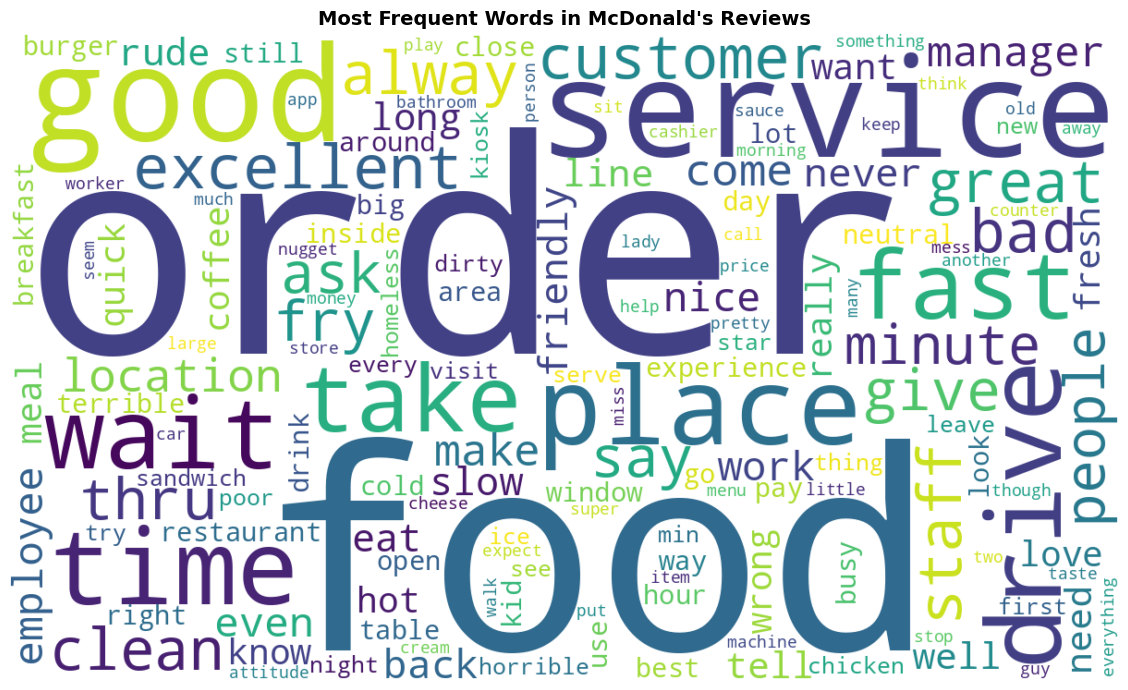

In [24]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# df_model already has the "tokens" column from Stage 2 preprocessing
all_text = " ".join([" ".join(tokens) for tokens in store_model["tokens"]])

wc = WordCloud(
    width=1200,
    height=700,
    background_color="white",
    colormap="viridis",
    max_words=150,
    collocations=False
).generate(all_text)

plt.figure(figsize=(12, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in McDonald's Reviews", fontsize=14, weight="bold")
plt.tight_layout()
plt.savefig("wordcloud_all_reviews.png", dpi=150)
plt.show()

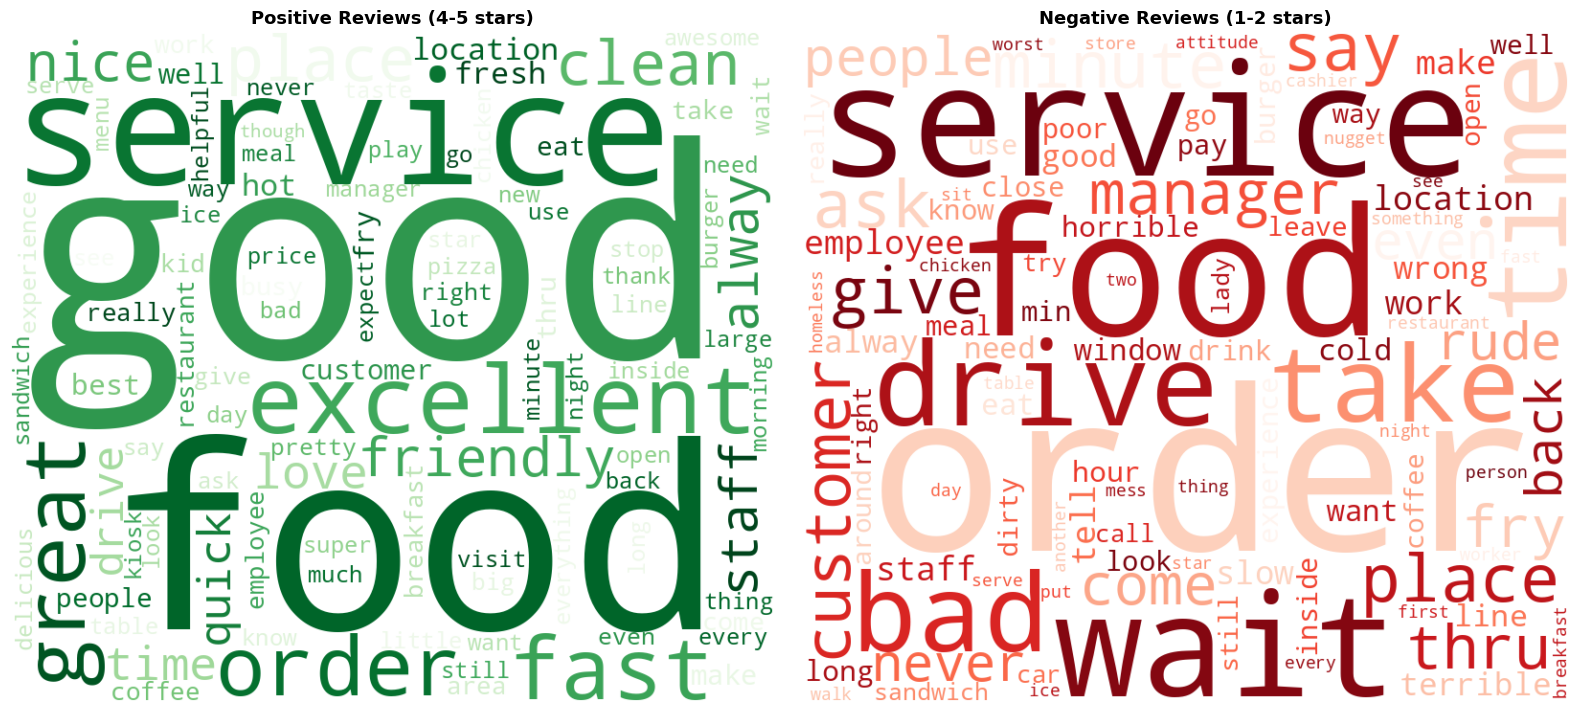

In [25]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_text = " ".join([" ".join(t) for t in store_model[store_model["rating"] >= 4]["tokens"]])
negative_text = " ".join([" ".join(t) for t in store_model[store_model["rating"] <= 2]["tokens"]])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

wc_pos = WordCloud(width=800, height=700, background_color="white",
                    colormap="Greens", max_words=100, collocations=False).generate(positive_text)
axes[0].imshow(wc_pos, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Positive Reviews (4-5 stars)", fontsize=13, weight="bold")

wc_neg = WordCloud(width=800, height=700, background_color="white",
                    colormap="Reds", max_words=100, collocations=False).generate(negative_text)
axes[1].imshow(wc_neg, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Negative Reviews (1-2 stars)", fontsize=13, weight="bold")

plt.tight_layout()
plt.savefig("wordcloud_positive_vs_negative.png", dpi=150)
plt.show()

### 2.9 Summary of Task 2

The preprocessing pipeline applied five steps in sequence, each removing a specific type of noise:

1. **Lowercase** — merges case variants of the same word (e.g. "Food"/"food").
2. **Remove punctuation and numbers** — strips symbols and digits that carry no topical meaning.
3. **Tokenise** — splits each review into a list of individual words for downstream processing.
4. **Remove stop words** — drops common filler words (and the brand name) that appear everywhere and would otherwise dominate every topic.
5. **Lemmatise** — reduces words to their dictionary root form using part-of-speech tagging, so related words like "fry"/"fries"/"fried" are counted as one concept.

# Task 3: Build an LDA Model

LDA (Latent Dirichlet Allocation) assumes every review is a mix of topics, and every topic is a mix of words. Given the cleaned tokens from task 2, the model works backward from word co-occurrence patterns to infer what those underlying topics are. This section builds the model, picks the number of topics with evidence rather than guesswork, and names each topic based on its top words.



# 3.1 Build the dictionary and corpus

In [26]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 49.3 MB/s eta 0:00:00


In [27]:
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

texts = store_model["tokens"].tolist()

# Dictionary: maps every unique word in the corpus to an integer ID
dictionary = corpora.Dictionary(texts)
print(f"Vocabulary size before filtering: {len(dictionary)}")

# Remove words that are too rare or too common to be useful for separating topics
dictionary.filter_extremes(no_below=5, no_above=0.5)
print(f"Vocabulary size after filtering: {len(dictionary)}")

# Bag-of-words corpus: each review becomes a list of (word_id, count) pairs
corpus = [dictionary.doc2bow(t) for t in texts]

Vocabulary size before filtering: 11008
Vocabulary size after filtering: 3399


**Filter vocabulary:** `no_below=5` drops words that appear in fewer than 5 reviews — these are usually typos, rare brand names, or one-off phrasing that add noise without helping the model find patterns. `no_above=0.5` drops words that appear in more than 50% of reviews — a word that common behaves like a stop word for this specific corpus and does not help distinguish one topic from another. Filtering shrinks the vocabulary from over 11,000 words to a more manageable, meaningful set, which also makes the model faster and less prone to overfitting on noise.

LDA is a bag-of-words model: it only cares about which words appear in a document and how often, not their order. The `doc2bow` step converts each review's token list into this word-count format.

# 3.2 Determine an appropriate number of topics

Picking the number of topics (k) is the most important modelling decision in LDA. Too few topics and distinct themes get merged together; too many and the model splits a single theme into fragments that are hard to interpret.

The standard, evidence-based approach is to train several models across a range of k values and score each one using topic coherence `(c_v)`, which measures how semantically related the top words within each topic are, based on how often they co-occur in the actual text. Higher coherence generally means more interpretable topics.

In [28]:
import time

topic_range = range(2, 11)
coherence_scores = []

for k in topic_range:
    t0 = time.time()
    lda_temp = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=5,
        iterations=50,
        alpha="auto",
        eta="auto"
    )
    cm = CoherenceModel(model=lda_temp, texts=texts, dictionary=dictionary, coherence="c_v")
    score = cm.get_coherence()
    coherence_scores.append(score)
    print(f"k={k}: coherence={score:.4f}  ({time.time()-t0:.1f}s)")

k=2: coherence=0.6872  (35.1s)


k=3: coherence=0.6456  (29.7s)


k=4: coherence=0.6593  (34.5s)
k=5: coherence=0.6512  (35.8s)
k=6: coherence=0.6181  (36.0s)
k=7: coherence=0.6511  (37.2s)
k=8: coherence=0.6134  (34.3s)
k=9: coherence=0.6078  (36.9s)
k=10: coherence=0.6254  (37.5s)


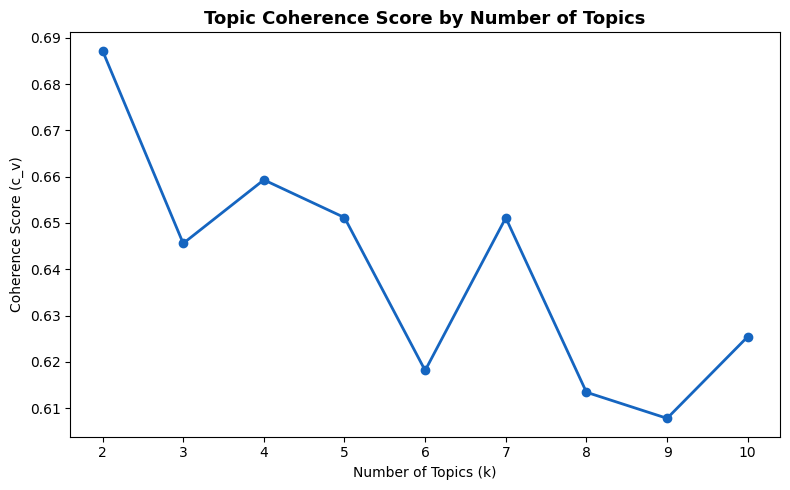

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(topic_range), coherence_scores, marker="o", color="#1565c0", linewidth=2)
ax.set_title("Topic Coherence Score by Number of Topics", fontsize=13, weight="bold")
ax.set_xlabel("Number of Topics (k)")
ax.set_ylabel("Coherence Score (c_v)")
ax.set_xticks(list(topic_range))
plt.tight_layout()
plt.savefig("coherence_scores.png")
plt.show()

**Visualisation 3: Coherence score by number of topics.**

Coherence alone points toward very low values of k (2-4), which is a known limitation of the c_v metric on corpora made of many short documents: it rewards a small number of broad, loosely-related topics because there is less opportunity for word co-occurrence to disagree. A 2-topic model would technically score well but would be useless for the business question, since it would likely just split reviews into "good" and "bad" without saying anything about why.

Because of this, the number of topics should not be chosen from the coherence score alone. The next step is to qualitatively inspect the top words at a shortlist of candidate k values near the top of the coherence curve, and choose the one that produces the most distinct, business-actionable themes.

3.3 Qualitative comparison of candidate topic counts

In [30]:
candidate_ks = [4, 5, 6, 7]

for k in candidate_ks:
    print(f"\n{'='*25} k = {k} {'='*25}")
    lda_temp = LdaModel(corpus=corpus, id2word=dictionary, num_topics=k, random_state=42,
                         passes=5, iterations=50, alpha="auto", eta="auto")
    for i in range(k):
        top_words = [w for w, _ in lda_temp.show_topic(i, topn=8)]
        print(f"Topic {i}: {top_words}")


========================= k = 4 =========================


Topic 0: ['drive', 'wait', 'thru', 'minute', 'order', 'line', 'long', 'fry']
Topic 1: ['order', 'time', 'give', 'ask', 'like', 'manager', 'make', 'say']
Topic 2: ['service', 'food', 'fast', 'great', 'staff', 'always', 'bad', 'slow']
Topic 3: ['good', 'place', 'clean', 'excellent', 'nice', 'kid', 'area', 'busy']

========================= k = 5 =========================
Topic 0: ['drive', 'wait', 'thru', 'order', 'minute', 'line', 'long', 'take']
Topic 1: ['order', 'time', 'give', 'ask', 'manager', 'make', 'say', 'come']
Topic 2: ['service', 'food', 'fast', 'great', 'staff', 'clean', 'always', 'friendly']
Topic 3: ['good', 'excellent', 'place', 'best', 'area', 'kid', 'neutral', 'eat']
Topic 4: ['fry', 'coffee', 'burger', 'like', 'ice', 'big', 'sandwich', 'chicken']

========================= k = 6 =========================
Topic 0: ['drive', 'wait', 'thru', 'line', 'long', 'minute', 'hour', 'close']
Topic 1: ['order', 'time', 'take', 'manager', 'say', 'give', 'food', 'ask']
Topic 2: ['s

**Inspection results:**

- **k=4-5:** Topics are broad and some themes bleed into each other — for example, "wait time" and "order problems" merge into a single topic, and general food-quality words mix with service words.
- **k=6:** Themes start separating cleanly, but staff rudeness and slow service are still combined into one topic.
- **k=7:** Each topic maps to a distinct, actionable theme: drive-thru/wait times, general order delays, rude staff/poor customer service, order accuracy (wrong or missing items), food and menu items, positive fast/clean/friendly service, and cleanliness complaints (dirty tables, bathrooms). This is the smallest k at which every topic is both internally coherent and clearly different from the others.

**Decision: k=7.** Its coherence score (see the chart above) is close to the scores at k=4 and k=5, so little statistical quality is sacrificed, while the qualitative gain in interpretability and business usefulness is substantial. This reflects standard practice in applied topic modelling: coherence scores guide the search, but the final choice should be validated by reading the actual topic content against the business question.

3.4 Train the final LDA model

In [31]:
NUM_TOPICS = 7

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=10,
    iterations=100,
    alpha="auto",
    eta="auto"
)

final_coherence = CoherenceModel(model=lda_model, texts=texts, dictionary=dictionary, coherence="c_v").get_coherence()
print(f"Final model coherence (k={NUM_TOPICS}): {final_coherence:.4f}")

Final model coherence (k=7): 0.6313


The final model uses more passes (10) and iterations (100) than the scan above, since it only needs to be trained once and can afford a more thorough fit.

3.5 Top words for each topic

In [32]:
topic_words = {}
for i in range(NUM_TOPICS):
    words_scores = lda_model.show_topic(i, topn=10)
    topic_words[i] = [w for w, _ in words_scores]

topic_words_store = pd.DataFrame(topic_words).T
topic_words_store.columns = [f"word_{i+1}" for i in range(10)]
topic_words_store.index.name = "topic_id"
topic_words_store

,word_1,word_2,word_3,word_4,word_5,word_6,word_7,word_8,word_9,word_10
topic_id,,,,,,,,,,
0,drive,wait,thru,minute,line,long,hour,close,open,min
1,like,say,time,ask,give,come,people,work,back,make
2,bad,customer,ever,service,rude,terrible,employee,horrible,experience,manager
3,order,take,wrong,right,time,kiosk,neutral,miss,item,correct
4,fry,meal,coffee,cold,burger,breakfast,big,sandwich,ice,chicken
5,food,service,place,fast,staff,great,clean,always,excellent,slow
6,good,table,lot,dirty,pretty,price,bathroom,much,zoo,attention


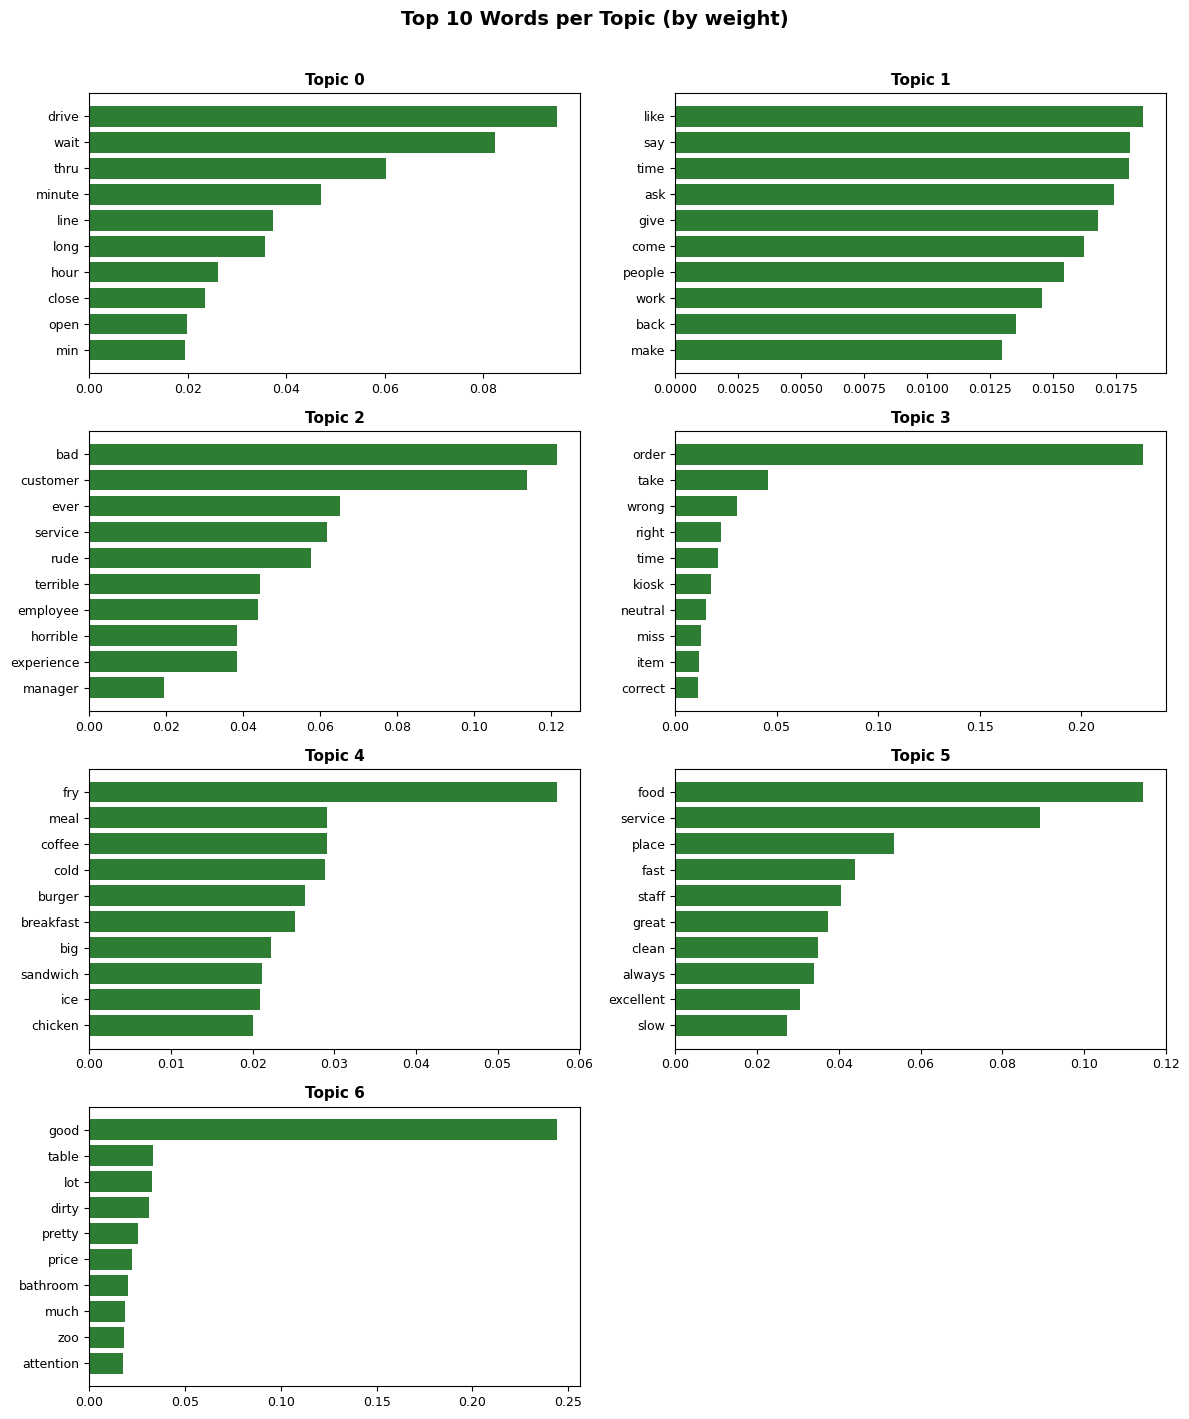

In [33]:
fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()

for i in range(NUM_TOPICS):
    words_scores = lda_model.show_topic(i, topn=10)
    words = [w for w, _ in words_scores][::-1]
    scores = [s for _, s in words_scores][::-1]
    axes[i].barh(words, scores, color="#2e7d32")
    axes[i].set_title(f"Topic {i}", fontsize=11, weight="bold")
    axes[i].tick_params(labelsize=9)

axes[-1].axis("off")  # hide the unused 8th subplot
plt.suptitle("Top 10 Words per Topic (by weight)", fontsize=14, weight="bold", y=1.01)
plt.tight_layout()
plt.savefig("topic_top_words.png")
plt.show()

**Visualisation 4: Top words per topic.**

Each bar chart shows the words the model weighted most heavily for that topic. The word weight reflects how strongly that word is associated with the topic relative to other topics, not how frequently it appears overall.

3.6 Name each topic

In [34]:
topic_names = {
    0: "Drive-Thru & Wait Times",
    1: "Order Delays & Follow-Up",
    2: "Rude Staff & Poor Customer Service",
    3: "Order Accuracy (Wrong / Missing Items)",
    4: "Food & Menu Items",
    5: "Fast, Clean, Friendly Service (Positive)",
    6: "Cleanliness & Facility Complaints",
}

for i in range(NUM_TOPICS):
    print(f"Topic {i}: {topic_names[i]}")
    print(f"  Top words: {topic_words[i]}\n")

Topic 0: Drive-Thru & Wait Times
  Top words: ['drive', 'wait', 'thru', 'minute', 'line', 'long', 'hour', 'close', 'open', 'min']

Topic 1: Order Delays & Follow-Up
  Top words: ['like', 'say', 'time', 'ask', 'give', 'come', 'people', 'work', 'back', 'make']

Topic 2: Rude Staff & Poor Customer Service
  Top words: ['bad', 'customer', 'ever', 'service', 'rude', 'terrible', 'employee', 'horrible', 'experience', 'manager']

Topic 3: Order Accuracy (Wrong / Missing Items)
  Top words: ['order', 'take', 'wrong', 'right', 'time', 'kiosk', 'neutral', 'miss', 'item', 'correct']

Topic 4: Food & Menu Items
  Top words: ['fry', 'meal', 'coffee', 'cold', 'burger', 'breakfast', 'big', 'sandwich', 'ice', 'chicken']

Topic 5: Fast, Clean, Friendly Service (Positive)
  Top words: ['food', 'service', 'place', 'fast', 'staff', 'great', 'clean', 'always', 'excellent', 'slow']

Topic 6: Cleanliness & Facility Complaints
  Top words: ['good', 'table', 'lot', 'dirty', 'pretty', 'price', 'bathroom', 'much'

| Topic | Name | Top words | Reasoning |
|---|---|---|---|
| 0 | Drive-Thru & Wait Times | drive, thru, wait, line, long, hour, close, open | Words describe queuing and drive-thru delays specifically |
| 1 | Order Delays & Follow-Up | time, wait, order, say, food, come, ask, minute | General complaints about time spent waiting on an order |
| 2 | Rude Staff & Poor Customer Service | bad, service, customer, rude, terrible, employee, horrible, manager | Negative words paired with people/service terms |
| 3 | Order Accuracy | order, wrong, kiosk, miss, correct, item | Words describe incorrect or incomplete orders |
| 4 | Food & Menu Items | fry, coffee, burger, sandwich, chicken, breakfast | Product names, not service-related |
| 5 | Fast, Clean, Friendly Service | food, service, fast, great, clean, staff, excellent, nice | Positive adjectives paired with service/staff terms |
| 6 | Cleanliness & Facility Complaints | dirty, table, bathroom, restroom, price, place | Physical environment and facility hygiene words |

This mapping will be used directly in task 4 to separate complaint themes from positive themes.

3.7 Interactive topic visualisation (pyLDAvis)

In [35]:
!pip install pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 28.0 MB/s eta 0:00:00


In [36]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model, corpus, dictionary)
pyLDAvis.save_html(vis, "lda_visualisation.html")
vis

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.098327  0.108727       1        1  35.093153
5     -0.241764  0.063564       2        1  18.099495
3      0.212433  0.075729       3        1  11.809679
0      0.161507  0.174063       4        1  11.348650
4      0.109566 -0.156580       5        1  10.445236
6     -0.028744 -0.371665       6        1   6.899853
2     -0.311324  0.106162       7        1   6.303935, topic_info=          Term         Freq        Total Category  logprob  loglift
49       order  9326.000000  9326.000000  Default  30.0000  30.0000
420       good  5718.000000  5718.000000  Default  29.0000  29.0000
7         food  7661.000000  7661.000000  Default  28.0000  28.0000
64     service  6797.000000  6797.000000  Default  27.0000  27.0000
69       drive  3660.000000  3660.000000  Default  26.0000  26.0000
..         ...          ...          ...      ...      ...      ...
321      avoid   142.983453   217.539462   Topic7  -5.0081   2.3443
43     manager   415.836543  1952.971855   Topic7  -3.9406   1.2172
253  extremely   108.680123   256.221900   Topic7  -5.2825   1.9064
422       care    99.406024   406.180247   Topic7  -5.3717   1.3564
79        need    97.723344  1265.169002   Topic7  -5.3887   0.2032

[350 rows x 6 columns], token_table=      Topic      Freq    Term
term                         
815       3  0.044437  across
815       6  0.952229  across
1247      3  0.016291     act
1247      7  0.977466     act
1119      6  0.990408    alot
...     ...       ...     ...
452       7  0.999020   worst
867       7  0.981444     wow
87        3  0.999218   wrong
137       1  0.998135   young
3168      6  0.998661     zoo

[504 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 6, 4, 1, 5, 7, 3])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


`pyLDAvis` renders an interactive map of the topics: each circle is a topic, circle size reflects how prevalent that topic is across the corpus, and distance between circles reflects how different the topics are from each other. Clicking a topic shows its most relevant terms on the right, with a slider to adjust between term frequency within the topic and term exclusivity to the topic.

### 3.8 Assign each review to its dominant topic

This step will also be used in task 4 to quantify how many reviews fall into each theme, and to link topics back to star ratings.

In [37]:
def get_dominant_topic(bow):
    topic_probs = lda_model.get_document_topics(bow)
    return max(topic_probs, key=lambda x: x[1])[0]

store_model["dominant_topic"] = [get_dominant_topic(bow) for bow in corpus]
store_model["dominant_topic_name"] = store_model["dominant_topic"].map(topic_names)

store_model["dominant_topic_name"].value_counts()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,count
dominant_topic_name,
Order Delays & Follow-Up,16713
"Fast, Clean, Friendly Service (Positive)",11450
Drive-Thru & Wait Times,1464
Food & Menu Items,1444
Order Accuracy (Wrong / Missing Items),1054
Cleanliness & Facility Complaints,399
Rude Staff & Poor Customer Service,350


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

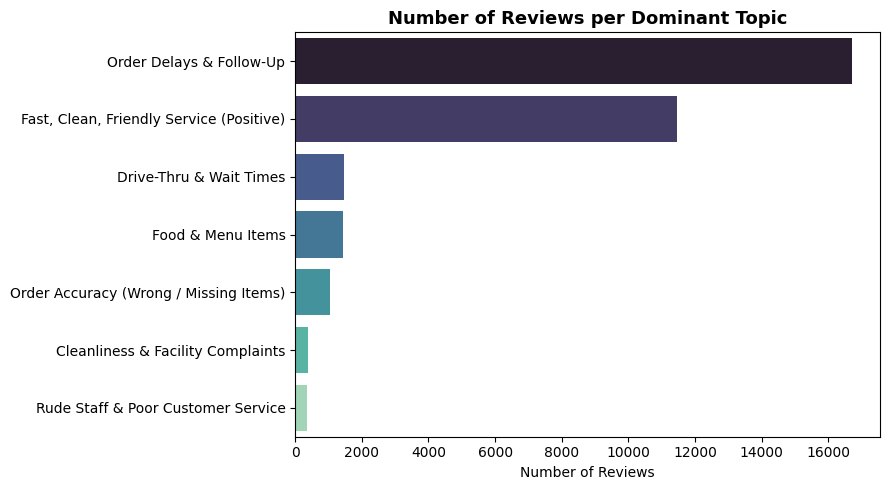

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [38]:
fig, ax = plt.subplots(figsize=(9, 5))
topic_counts = store_model["dominant_topic_name"].value_counts()
sns.barplot(x=topic_counts.values, y=topic_counts.index, hue=topic_counts.index, palette="mako", legend=False, ax=ax)
ax.set_title("Number of Reviews per Dominant Topic", fontsize=13, weight="bold")
ax.set_xlabel("Number of Reviews")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("reviews_per_topic.png")
plt.show()

### 3.9 Summary of Task 3

- Built a bag of words corpus from the cleaned tokens, filtering out words that were too rare (fewer than 5 reviews) or too common (over 50% of reviews) to be useful for separating topics.
- Scanned coherence scores across k=2 to k=10, then combined this with a qualitative reading of topic content, since coherence alone favoured an uninformatively small number of topics.
- Selected **k=7** as the number of topics: it produces the smallest model where every topic is both internally coherent and clearly distinct from the others.
- Named each of the 7 topics based on its top words, spanning both complaint themes (wait times, rude staff, order accuracy, cleanliness) and positive themes (fast/clean/friendly service) plus a general food/menu topic.
- Saved an interactive `pyLDAvis` visualisation (`lda_visualisation.html`) .
- Assigned every review its dominant topic, setting up Task 4's deeper interpretation of what these themes mean for McDonald's.

## Task 4: Interpret the Results

Last aspect produced seven topics and assigned each review a dominant topic. This section connects those topics back to star ratings and actual review text, to work out which themes represent complaints, which represent positive experiences, and what the biggest takeaways are for McDonald's.

4.1 Average rating by topic

In [39]:
topic_summary = store_model.groupby("dominant_topic_name").agg(
    review_count=("rating", "count"),
    avg_rating=("rating", "mean")
).round(2).sort_values("avg_rating")

topic_summary["share_of_reviews_%"] = (topic_summary["review_count"] / len(store_model) * 100).round(1)
topic_summary

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,review_count,avg_rating,share_of_reviews_%
dominant_topic_name,,,
Rude Staff & Poor Customer Service,350,1.54,1.1
Drive-Thru & Wait Times,1464,2.27,4.5
Order Accuracy (Wrong / Missing Items),1054,2.42,3.2
Order Delays & Follow-Up,16713,2.58,50.8
Food & Menu Items,1444,2.79,4.4
Cleanliness & Facility Complaints,399,3.44,1.2
"Fast, Clean, Friendly Service (Positive)",11450,4.18,34.8


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

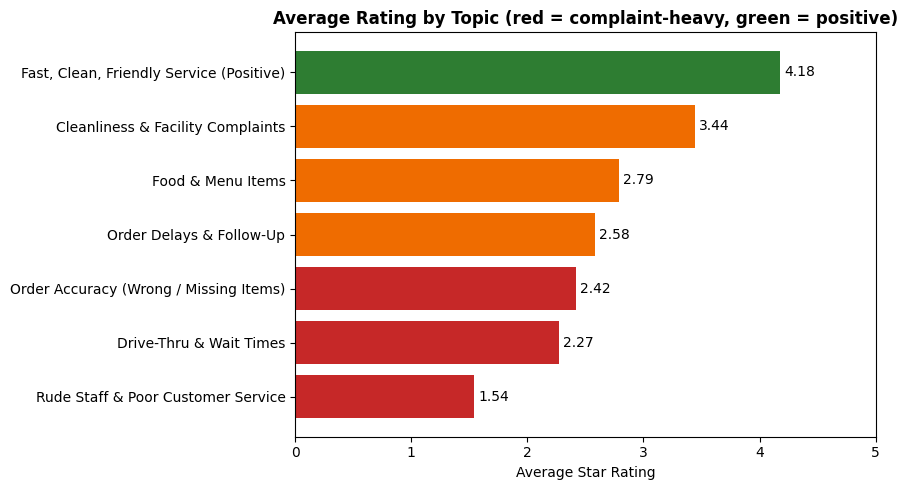

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [40]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#c62828" if r < 2.5 else "#ef6c00" if r < 3.5 else "#2e7d32" for r in topic_summary["avg_rating"]]
bars = ax.barh(topic_summary.index, topic_summary["avg_rating"], color=colors)
ax.set_xlabel("Average Star Rating")
ax.set_title("Average Rating by Topic (red = complaint-heavy, green = positive)", fontsize=12, weight="bold")
ax.set_xlim(0, 5)
ax.bar_label(bars, fmt="%.2f", padding=3)
plt.tight_layout()
plt.savefig("avg_rating_by_topic.png")
plt.show()

**Visualisation 5**

Average rating by topic. This confirms the topics split cleanly along sentiment lines, which validates that the LDA model, though trained without ever seeing the star ratings, independently rediscovered the same complaint/praise split that ratings capture. That agreement is a good sign the topics are picking up genuine signal rather than noise.

### 4.2 Representative example reviews per topic

In [41]:
# Get how strongly each review belongs to its dominant topic
dominant_probs = []
for bow in corpus:
    topic_probs = lda_model.get_document_topics(bow)
    best_prob = max(topic_probs, key=lambda x: x[1])[1]
    dominant_probs.append(best_prob)
store_model["dominant_topic_prob"] = dominant_probs

def show_examples(topic_id, n=3):
    subset = store_model[store_model["dominant_topic"] == topic_id].sort_values("dominant_topic_prob", ascending=False)
    print(f"=== {topic_names[topic_id]} ===")
    shown = set()
    count = 0
    for _, row in subset.iterrows():
        if row["review"] in shown:
            continue
        shown.add(row["review"])
        print(f"  [{row['rating']} star] {row['review'][:150]}")
        count += 1
        if count == n:
            break
    print()

for i in range(NUM_TOPICS):
    show_examples(i)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

=== Drive-Thru & Wait Times ===
  [1 star] Long wait times for the drive-thru. They jerk you around with their open/close times, too. They close at eleven, I drove by at 10 after ten and they s
  [1 star] The hours say they are open at 5:00am but it's 5:30 and the doors are  locked. I have been waiting for half an hour and still not open only drive thru
  [1 star] Drive thru was closed today. 10/9 at 3:45am. Is it still 24 hours if the drive thru is closed and the dining room as well? Park your car and wait, or 

=== Order Delays & Follow-Up ===
  [1 star] There was hair in my food so i took it back and when i told the manager she said to me, " theres no possible way there could be hair in our food." I l
  [1 star] I got a sundae and My sundae got knocked over when I went to sit down , I asked the manager in the picture below for a new shake and he said itï¿½ï¿½ï
  [1 star] Very very rude employees, rushing you to hurry up and when giving you your food they throw it on the counter and 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

**Sort by dominant topic probability** The reviews shown for each topic are the ones the model is most confident belong to that topic, which makes them the clearest, most representative examples of what that theme is actually about.

# Task 5: Business Recommendations

**1. Fix order accuracy in mobile and kiosk ordering**

The Order Accuracy topic (2.42 avg rating) shows missing or wrong items as a recurring complaint, especially tied to app orders and kiosk pickup. Add a mandatory order-check step before handing food to customers. Print a checklist on kiosk receipts listing every item ordered, so staff and customers verify together at pickup.

**2. Standardize drive-thru hours and staffing**

Drive-Thru & Wait Times (2.27 avg rating) shows a specific, fixable problem: posted hours don't match reality, and drive-thru lanes close without notice. Audit posted hours against actual staffing schedules at every location. Post real-time closure alerts on Google Maps and the app when a lane goes down.

**3. Reduce order delays and improve complaint recovery**

Order Delays & Follow-Up is the largest topic, covering roughly half of all reviews (2.58 avg rating). The core issue isn't only speed. It's how staff handle problems once something goes wrong (a dismissed complaint, a knocked-over order, incorrect change). Train shift managers on a standard recovery script: acknowledge the issue, offer a concrete fix (replacement, refund, voucher), and follow up. This single fix touches the highest number of customers.

**4. Target customer service training at specific low-performing locations**

Rude Staff & Poor Customer Service has the lowest average rating of any topic (1.54) but the smallest volume (about 1% of reviews). This pattern points to a small number of stores or shifts, not a system-wide culture problem. Pull the store-level breakdown for this topic and run focused retraining or management changes at the specific locations driving it, rather than a blanket company-wide campaign.

**5. Set a consistent cleanliness standard across locations**

Cleanliness & Facility Complaints has a mixed rating spread (3.44 avg), meaning some stores earn praise for clean, well-kept spaces while others get complaints about dirty tables and restrooms. Standardize a cleaning checklist with set intervals (hourly table wipes, restroom checks every two hours) and audit compliance during store visits, since this topic shows the standard already exists at some locations and simply isn't enforced everywhere.